In [32]:
import pymc as pm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
# import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az
import random
# import math

### Real data to use (eventually)

In [14]:
df = pd.read_parquet('./../data/processed/bioasq_embeddings_subset.parquet')

X = np.stack(df['embedding'].values)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,         # 20% of data goes into test set
    random_state=42,       # For reproducibility
    stratify=y             # Ensures class distribution is preserved
)

### Toy data for demo purposes

In [ ]:
# np.random.seed(42)
# num_samples = 100
# embedding_dim = 10
# X = np.random.rand(num_samples, embedding_dim)
# y = np.random.randint(0, 2, num_samples)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
with pm.Model() as logistic_model:
    # define X_train as a pm.Data object
    X_train_shared = pm.Data('X_train', X_train)
    
    # Priors for the coefficients (weights)
    weights = pm.Normal('weights', mu=0, sigma=1, shape=X_train.shape[1])

    # Prior for the intercept (bias)
    intercept = pm.Normal('intercept', mu=0, sigma=1)

    # Linear combination of features and weights
    linear_predictor = pm.math.dot(X_train_shared, weights) + intercept

    # Logistic transformation to get the probability of the 'relevant' class (y=1)
    p = pm.Deterministic('p', pm.math.sigmoid(linear_predictor))

    # Likelihood function (Bernoulli distribution for binary labels)
    likelihood = pm.Bernoulli('likelihood', p=p, observed=y_train)

    # Sample from the posterior distribution using MCMC
    idata = pm.sample(2000, tune=1000, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [weights, intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


In [ ]:
# pm.Model

In [ ]:
# logistic_model.set_data()

In [16]:
# Use the sampled posterior to predict probabilities for the test set
with logistic_model:
    pm.set_data({'X_train': X_test}) # updating the pm.Data() object
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])


Sampling: []


Output()

In [ ]:
# Extract the predicted probabilities
predicted_probabilities = posterior_predictive.posterior_predictive['p'].mean(dim=('chain', 'draw')).values

In [20]:
# Convert probabilities to class labels (threshold can be adjusted as appropriate)
y_pred_bayes = (predicted_probabilities > 0.5).astype(int)

In [21]:
# Evaluate accuracy score 
accuracy_bayes = accuracy_score(y_test, y_pred_bayes)
print(f"\nBayesian Logistic Regression Accuracy: {accuracy_bayes:.2f}")
print("Bayesian Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_bayes))


Bayesian Logistic Regression Accuracy: 0.83
Bayesian Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        21
           1       0.89      0.76      0.82        21

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.84      0.83      0.83        42



### Examining the probability distributions for predictions

In [22]:
for i in range(len(X_test)):
    prob_distribution = posterior_predictive.posterior_predictive['p'][:, :, 1].values.flatten()

    mean_prob = np.mean(prob_distribution)
    std_prob = np.std(prob_distribution)
    print(f"Document {i+1}: Mean P(Relevant) = {mean_prob:.3f}, Std P(Relevant) = {std_prob:.3f}")


Document 1: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 2: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 3: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 4: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 5: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 6: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 7: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 8: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 9: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 10: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 11: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 12: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 13: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 14: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 15: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
Document 16: Mean P(Relevant) = 0.499, Std P(Relevant) = 0.105
D

### Examining the Posterior Distribution of Weights and Intercept

In [23]:
az.summary(idata, var_names=['weights', 'intercept'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
weights[0],0.205,1.003,-1.710,2.081,0.010,0.014,10994.0,4997.0,1.0
weights[1],-0.033,1.000,-1.923,1.783,0.009,0.013,12275.0,4838.0,1.0
weights[2],0.053,1.021,-1.908,1.976,0.009,0.014,12930.0,5123.0,1.0
weights[3],-0.047,1.016,-1.974,1.822,0.009,0.013,12170.0,5159.0,1.0
weights[4],0.028,0.992,-1.849,1.880,0.010,0.013,10786.0,5377.0,1.0
...,...,...,...,...,...,...,...,...,...
weights[1532],0.187,1.003,-1.686,2.115,0.009,0.013,11806.0,5206.0,1.0
weights[1533],0.125,1.004,-1.757,1.972,0.009,0.014,12707.0,5474.0,1.0
weights[1534],0.150,0.999,-1.772,1.990,0.010,0.013,9925.0,5363.0,1.0
weights[1535],-0.055,0.990,-1.905,1.817,0.009,0.013,11955.0,5606.0,1.0


array([[<Axes: title={'center': 'weights'}>,
        <Axes: title={'center': 'weights'}>],
       [<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>]], dtype=object)

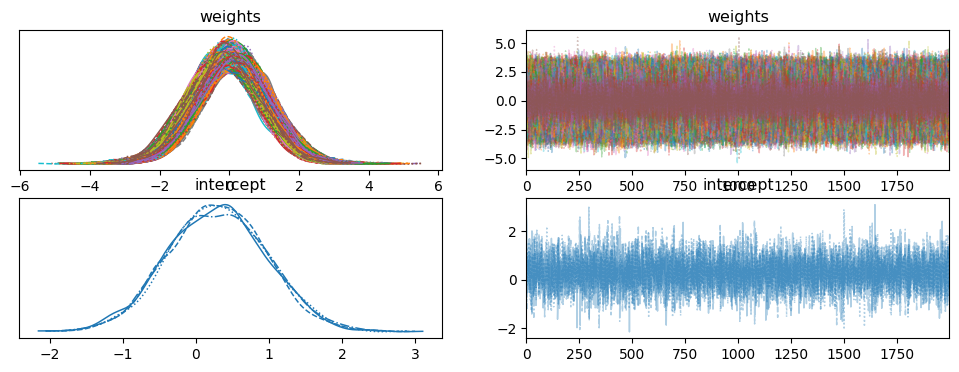

In [26]:
az.plot_trace(idata, var_names=['weights', 'intercept'])

### Posterior distribution for a single prediction

23

In [ ]:
# Choose the index of the test instance you want to visualize
test_instance_index = random.randrange(len(X_test))
single_test_instance = X_test[test_instance_index].reshape(1, -1)

with logistic_model:
    pm.set_data({'X_train': single_test_instance})
    posterior_predictive_single = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])

# Extract the posterior predictive samples for the chosen instance
posterior_probabilities_single = posterior_predictive_single.posterior_predictive['p'].values.flatten()

# Calculate the 95% credible interval
credible_interval = az.hdi(posterior_probabilities_single, hdi_prob=0.95)
lower_bound = credible_interval[0]
upper_bound = credible_interval[1]

Sampling: []


Output()

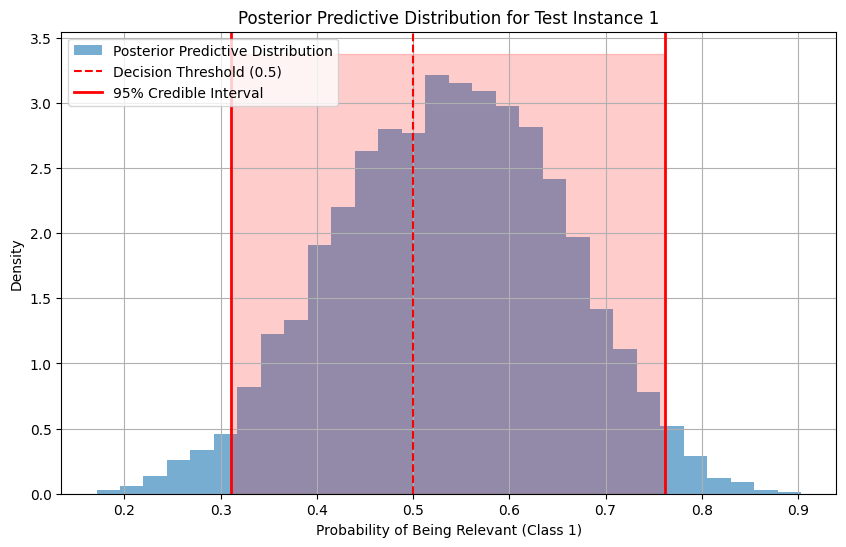

In [31]:
# Create the visualization
plt.figure(figsize=(10, 6))
plt.hist(posterior_probabilities_single, bins=30, density=True, alpha=0.6, label='Posterior Predictive Distribution')

# Plot the decision threshold
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')

# Plot the 95% credible interval
plt.axvline(lower_bound, color='red', linestyle='-', linewidth=2, label='95% Credible Interval')
plt.axvline(upper_bound, color='red', linestyle='-', linewidth=2)
plt.fill_betweenx(y=[0, plt.ylim()[1]], x1=lower_bound, x2=upper_bound, color='red', alpha=0.2)

# Add labels and title
plt.xlabel('Probability of Being Relevant (Class 1)')
plt.ylabel('Density')
plt.title(f'Posterior Predictive Distribution for Test Instance {test_instance_index + 1}')
plt.legend()
plt.grid(True)
plt.show()

### Data set of prediction data for all test set observations

In [38]:
with logistic_model:
    pm.set_data({'X_train': X_test})
    posterior_predictive_all = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])

Sampling: []


Output()

In [ ]:
posterior_probabilities_all = posterior_predictive_all.posterior_predictive['p'].values

In [54]:
prediction_data = []

for i in range(X_test.shape[0]):
    # get posterior probabilities for the current instance
    posterior_probs = posterior_probabilities_all[:, :, i].flatten()

    # calculate the 95% credible interval
    credible_interval = az.hdi(posterior_probs, hdi_prob=0.95)
    lower_bound = credible_interval[0]
    upper_bound = credible_interval[1]
    mean_probability = np.mean(posterior_probs)

    # store the data
    prediction_data.append({
        'doc_index': i,
        'posterior_samples': list(posterior_probs), # store the entire distribution
        'mean_probability': mean_probability,
        'ci_lower_bound': lower_bound,
        'ci_upper_bound': upper_bound,
        'ci_width': upper_bound - lower_bound,
        'true_label': y_test[i]
    })

predictions_df = pd.DataFrame(prediction_data)

In [55]:
predictions_df.head(3)

,doc_index,posterior_samples,mean_probability,ci_lower_bound,ci_upper_bound,ci_width,true_label
0,0,"[0.5415908852383395, 0.45054254509792074, 0.44...",0.536961,0.310784,0.761434,0.450651,1
1,1,"[0.606410989288179, 0.5106243417305623, 0.5573...",0.498965,0.300494,0.704670,0.404176,1
2,2,"[0.6217404091705419, 0.49168519200453126, 0.46...",0.553951,0.342147,0.759404,0.417257,1


In [48]:
mean_probability_by_label = predictions_df.groupby('true_label')['mean_probability'].mean()

In [49]:
mean_probability_by_label

true_label
0    0.461825
1    0.538488
Name: mean_probability, dtype: float64

In [59]:
summary_table = predictions_df.groupby('true_label').agg(
    mean_mean_prob = ('mean_probability', 'mean'),
    mean_lower_bound = ('ci_lower_bound', 'mean'),
    mean_upper_bound = ('ci_upper_bound', 'mean'),
    mean_ci_width = ('ci_width', 'mean'),
    sd_ci_width = ('ci_width', 'std')
).reset_index()

In [60]:
summary_table

,true_label,mean_mean_prob,mean_lower_bound,mean_upper_bound,mean_ci_width,sd_ci_width
0,0,0.461825,0.260486,0.664783,0.404297,0.017944
1,1,0.538488,0.327803,0.743814,0.416012,0.015725


In [62]:
predictions_df[predictions_df['ci_upper_bound'] < 0.664783]

,doc_index,posterior_samples,mean_probability,ci_lower_bound,ci_upper_bound,ci_width,true_label
4,4,"[0.5389603027679458, 0.460224318868791, 0.4346...",0.430860,0.243303,0.636650,0.393347,0
8,8,"[0.4763389714686087, 0.30365898332904995, 0.18...",0.448366,0.243183,0.664558,0.421374,0
11,11,"[0.2964534547207535, 0.45907251565819734, 0.46...",0.450171,0.257262,0.641788,0.384526,0
17,17,"[0.4284613578414791, 0.35613700164673345, 0.32...",0.406428,0.199781,0.600706,0.400925,0
22,22,"[0.480610320527775, 0.38809753756562104, 0.342...",0.421977,0.210819,0.654454,0.443635,0
27,27,"[0.4927754326873476, 0.45139138197853307, 0.32...",0.426874,0.222490,0.610428,0.387938,0
35,35,"[0.3998620720105475, 0.40666427070641004, 0.44...",0.426302,0.245123,0.615832,0.370709,0
36,36,"[0.5399662898836016, 0.4397845908464773, 0.390...",0.397474,0.201526,0.601694,0.400168,0
40,40,"[0.38071864118275067, 0.3574762779603187, 0.41...",0.423732,0.235526,0.610598,0.375072,0


Overall, the model's performance on the document embeddings I created resulted in an F-1 score of 0.83, which isn't bad. However, looking at this summary table, there doesn't seem to be a lot of difference between the distributions of documents that were irrelevant (true_label = 0) and documents that were relevant (true_label = 1).  

In [63]:
predictions_df[predictions_df['ci_lower_bound'] > 0.260486]

,doc_index,posterior_samples,mean_probability,ci_lower_bound,ci_upper_bound,ci_width,true_label
0,0,"[0.5415908852383395, 0.45054254509792074, 0.44...",0.536961,0.310784,0.761434,0.450651,1
1,1,"[0.606410989288179, 0.5106243417305623, 0.5573...",0.498965,0.300494,0.704670,0.404176,1
2,2,"[0.6217404091705419, 0.49168519200453126, 0.46...",0.553951,0.342147,0.759404,0.417257,1
3,3,"[0.565369352423783, 0.5385295759826075, 0.6148...",0.470871,0.272458,0.672431,0.399974,0
5,5,"[0.4568011691677651, 0.3090003589422345, 0.256...",0.482850,0.264146,0.689937,0.425791,0
6,6,"[0.6139810430533744, 0.48287555267827864, 0.66...",0.523319,0.320653,0.738509,0.417855,0
7,7,"[0.6800125416816201, 0.548486684000658, 0.5952...",0.575328,0.362001,0.784277,0.422276,1
10,10,"[0.671414276399821, 0.5747195461790038, 0.5644...",0.529810,0.319240,0.731302,0.412062,1
12,12,"[0.5137837071541764, 0.5358071399772949, 0.596...",0.599335,0.395006,0.794172,0.399166,1
13,13,"[0.5016299291032806, 0.40623859083626174, 0.30...",0.502175,0.286200,0.713716,0.427516,1
